Step 1: Problem Statement

Problem Statement:

 To predict whether a customer will purchase a product based on current Age, Gender and Annual Income



Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Step 3: Load Dataset

In [ ]:
japan_data = pd.read_excel("JPN Data.xlsx")
japan_data.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,445344.000000,439,0
1,00003I71CQ,35,M,107634.000000,283,0
2,00003N47FS,59,F,502786.666667,390,1
3,00005H41DE,43,M,585664.000000,475,0
4,00007E17UM,39,F,705722.666667,497,1


Step 4: Dataset Information

In [ ]:
print(japan_data.shape)
japan_data.info()
japan_data.describe()

(40000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          40000 non-null  object 
 1   CURR_AGE    40000 non-null  int64  
 2   GENDER      40000 non-null  object 
 3   ANN_INCOME  40000 non-null  float64
 4   AGE_CAR     40000 non-null  int64  
 5   PURCHASE    40000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ MB


,CURR_AGE,ANN_INCOME,AGE_CAR,PURCHASE
count,40000.00000,40000.000000,40000.000000,40000.000000
mean,44.99745,359398.878050,359.080250,0.575775
std,11.82008,175109.262950,203.063724,0.494231
min,25.00000,70089.000000,1.000000,0.000000
25%,35.00000,219766.000000,235.000000,0.000000
50%,45.00000,337656.833333,331.000000,1.000000
75%,55.00000,464261.000000,444.000000,1.000000
max,65.00000,799970.666667,1020.000000,1.000000


Step 5: Data Cleaning

In [ ]:
#Check Null Values
print(japan_data.isnull().sum())
#Check Duplicate Values
print(japan_data.duplicated().sum())
#Remove Duplicates
japan_data = japan_data.drop_duplicates()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64
0


In [ ]:
#Convert Gender to Numbers
japan_data["GENDER"] = japan_data["GENDER"].map({
    "M": 1,
    "F": 0
})
print(japan_data["GENDER"].unique())

[1 0]


Step 6: EDA

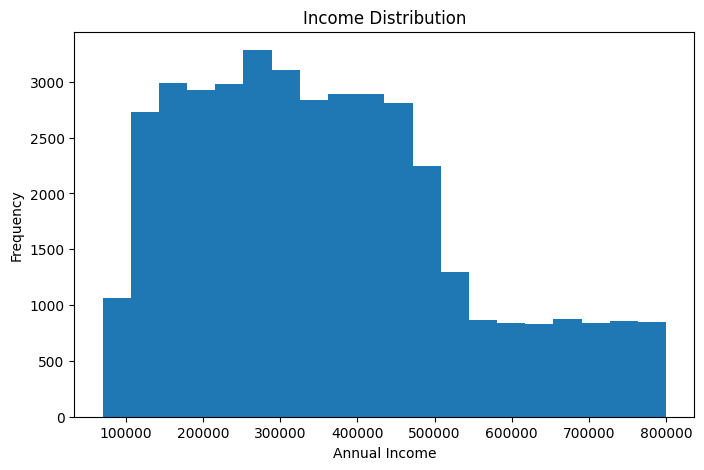

In [ ]:
#Income Distribution
plt.figure(figsize=(8,5))
plt.hist(japan_data["ANN_INCOME"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

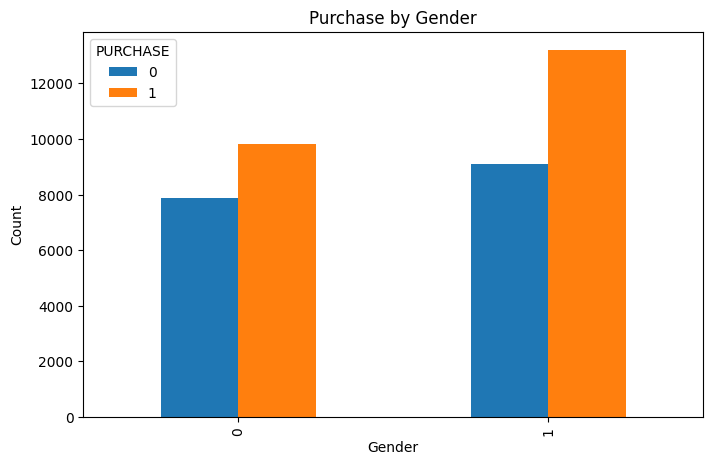

In [ ]:
#Purchase by Gender
purchase_gender = pd.crosstab(
    japan_data["GENDER"],
    japan_data["PURCHASE"]
)
purchase_gender.plot(kind='bar', figsize=(8,5))
plt.title("Purchase by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Step 7: Feature Selection

In [ ]:
X = japan_data[["CURR_AGE","GENDER","ANN_INCOME"]]
y = japan_data["PURCHASE"]

Step 8: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

Step 9: Feature Scaling

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Step 10: Build Model

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Step 11: Prediction

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 ... 1 1 0]


Step 12: Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
#Classification Report
print(classification_report(y_test,y_pred))

Accuracy = 0.628625
[[1007 2342]
 [ 629 4022]]
              precision    recall  f1-score   support

           0       0.62      0.30      0.40      3349
           1       0.63      0.86      0.73      4651

    accuracy                           0.63      8000
   macro avg       0.62      0.58      0.57      8000
weighted avg       0.63      0.63      0.59      8000



step 13:Conclusion

The main objective of this project was to predict customer purchase behavior using Machine Learning techniques. By analyzing customer information such as current age, gender, and annual income, the Logistic Regression model was able to identify patterns that purchasing decisions.